In [1]:
"""
xLSTM for BiH air-quality forecasting — SPEED-OPTIMIZED version.

This is a drop-in replacement for cell 0 of xlstm_posljednja_sansa.ipynb.
Every public function name and signature that your later cells call
(train_one_station, evaluate, run_all, progress, plot_results,
inspect_outliers) is unchanged, so cells 1-8 (progress(), run_all(limit=5),
the Drive mount, final_summary()) work exactly as before — just faster.

WHAT WAS ACTUALLY SLOW, and what changed:

1. device="cpu" was hardcoded as the default everywhere, so even on a GPU
   runtime none of this ever touched the GPU. Fixed: DEVICE is auto-detected
   once at import time and used as the default everywhere. YOU STILL NEED TO
   pick a GPU runtime in Colab (Runtime > Change runtime type > T4 GPU or
   better) before running this cell — the code can detect it, but can't turn
   it on for you.

2. WindowDataset.__getitem__ called bs.context()/bs.target() from scratch
   for every sample, on every epoch. With epochs=20 that's 20x more calls
   into those (pandas-backed) helpers than necessary. Fixed: every window is
   precomputed ONCE into plain tensors before training starts
   (build_tensor_windows), then training just indexes into those tensors.

3. DataLoader adds real per-batch overhead (collation, python-side
   iteration) that matters more here because each "sample" is cheap once
   precomputed. Fixed: training loops over the precomputed tensors directly
   with torch.randperm-based mini-batching — no DataLoader in the hot loop.

4. Mixed precision (autocast + GradScaler) is now used automatically on
   CUDA, which speeds up the matmul-heavy mLSTM cell meaningfully.

5. Early stopping: the original logs (epoch 5: 0.3350, epoch 11: 0.3310)
   show train loss basically plateaus well before epoch 20. Training now
   stops once loss stops improving for `patience` epochs instead of always
   running the full budget.

6. batch_size default raised 64 -> 256, since precomputed tensors are small
   and bigger batches use the GPU (or even CPU BLAS) much more efficiently.

Everything about WHAT gets computed — eligibility rules, windowing,
standardization, masking, scoring against bs.score/bs.mase_scale/
bs.aggregate — is untouched. Only HOW FAST it gets there changed.
"""

import os
import sys
import time
import subprocess
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

SHARED_DIR = "shared"
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output=SHARED_DIR, quiet=True)
sys.path.append(SHARED_DIR)
import bih_shared as bs

CLEAN_CSV = "bih_hourly_clean.csv"
if not os.path.exists(CLEAN_CSV):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN_CSV, quiet=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("no GPU detected — go to Runtime > Change runtime type > GPU (T4 is fine) "
          "and rerun this cell for the biggest speedup available. Everything below "
          "still runs on CPU, just without that boost.")


# ---------------------------------------------------------------------------
# 1. Data loading — UNCHANGED from the original
# ---------------------------------------------------------------------------

def build_train_origins(panel, split, station, pollutant, horizon):
    s = panel[(station, pollutant)]
    y = s.y.to_numpy()
    filled = s.filled.to_numpy()
    real = ~np.isnan(y) & ~filled

    hour_of_day = split["origin_hour_of_day"]
    min_real_target = split["masking"]["min_real_target_hours"]

    train_start = pd.Timestamp(split["train"]["start"])
    train_end = pd.Timestamp(split["train"]["end"])
    candidates = s.index[(s.index >= train_start) & (s.index <= train_end)
                          & (s.index.hour == hour_of_day)]

    origins = []
    for ts in candidates:
        o = s.index.get_loc(ts)
        if o + horizon > len(y):
            continue
        if real[o:o + horizon].sum() < min_real_target:
            continue
        if not np.isfinite(y[max(0, o - 168):o]).any():
            continue
        origins.append(ts)
    return origins


def build_tensor_windows(panel, station, pollutant, origins, lookback, horizon, mu, sigma):
    """Precomputes every window's (input, target, mask) ONCE as plain numpy
    arrays -> tensors, instead of recomputing them from bs.context/bs.target
    inside a Dataset.__getitem__ that gets called every sample, every epoch.
    Same math as the original WindowDataset, just computed a single time."""
    sigma = sigma if sigma > 1e-6 else 1.0
    n = len(origins)
    X = np.zeros((n, lookback, 2), dtype=np.float32)
    Y = np.zeros((n, horizon), dtype=np.float32)
    M = np.zeros((n, horizon), dtype=np.float32)

    for i, origin in enumerate(origins):
        ctx = bs.context(panel, station, pollutant, origin, lookback)
        if len(ctx) < lookback:
            pad = np.full(lookback - len(ctx), np.nan, dtype=ctx.dtype)
            ctx = np.concatenate([pad, ctx])
        observed = np.isfinite(ctx).astype(np.float32)
        ctx_norm = np.nan_to_num((ctx - mu) / sigma, nan=0.0).astype(np.float32)

        y, mask = bs.target(panel, station, pollutant, origin, horizon)
        y_norm = np.nan_to_num((y - mu) / sigma, nan=0.0).astype(np.float32)

        X[i, :, 0] = ctx_norm
        X[i, :, 1] = observed
        Y[i] = y_norm
        M[i] = mask.astype(np.float32)

    return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(M)


class TensorWindows:
    """Replaces WindowDataset. Exposes the same .origins / .horizon that
    evaluate() reads, but X/Y/M are precomputed tensors already sitting on
    `device` — indexing them for a minibatch costs nothing extra."""

    def __init__(self, X, Y, M, origins, horizon, device):
        self.X = X.to(device)
        self.Y = Y.to(device)
        self.M = M.to(device)
        self.origins = origins
        self.horizon = horizon

    def __len__(self):
        return self.X.shape[0]


# ---------------------------------------------------------------------------
# 2. xLSTM blocks — UNCHANGED from the original (this is the actual model;
#    the per-timestep python loop here is inherent to xLSTM's recurrence and
#    wasn't touched, but running it on GPU with bigger batches parallelizes
#    the batch dimension at every one of those timesteps instead of doing
#    them one sample at a time on CPU)
# ---------------------------------------------------------------------------

class sLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size)
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h, c, n, m = state
        gates = self.W(x_t) + self.R(h)
        z, i_tilde, f_tilde, o_tilde = gates.chunk(4, dim=-1)

        z = torch.tanh(z)
        o = torch.sigmoid(o_tilde)

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        c_new = f * c + i * z
        n_new = f * n + i
        h_new = o * (c_new / n_new.clamp_min(1e-6))

        return h_new, (h_new, c_new, n_new, m_new)

    def init_state(self, batch_size, device):
        z = torch.zeros(batch_size, self.hidden_size, device=device)
        return (z, z, z, z)


class mLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wq = nn.Linear(input_size, hidden_size)
        self.Wk = nn.Linear(input_size, hidden_size)
        self.Wv = nn.Linear(input_size, hidden_size)
        self.Wi = nn.Linear(input_size, 1)
        self.Wf = nn.Linear(input_size, 1)
        self.Wo = nn.Linear(input_size, hidden_size)

    def forward(self, x_t, state):
        C, n, m = state

        q = self.Wq(x_t)
        k = self.Wk(x_t) / math.sqrt(self.hidden_size)
        v = self.Wv(x_t)
        i_tilde = self.Wi(x_t)
        f_tilde = self.Wf(x_t)
        o = torch.sigmoid(self.Wo(x_t))

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        C_new = f.unsqueeze(-1) * C + i.unsqueeze(-1) * torch.einsum("bh,bk->bhk", v, k)
        n_new = f * n + i * k

        h = o * torch.einsum("bhk,bk->bh", C_new, q) / \
            torch.einsum("bh,bh->b", n_new, q).clamp_min(1e-6).unsqueeze(-1)

        return h, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, device=device)
        n = torch.zeros(batch_size, self.hidden_size, device=device)
        m = torch.zeros(batch_size, 1, device=device)
        return (C, n, m)


class xLSTMBlock(nn.Module):
    def __init__(self, input_size, hidden_size, kind="m"):
        super().__init__()
        self.kind = kind
        self.cell = mLSTMCell(input_size, hidden_size) if kind == "m" else sLSTMCell(input_size, hidden_size)
        self.norm = nn.LayerNorm(input_size)
        self.proj = nn.Linear(hidden_size, input_size) if hidden_size != input_size else nn.Identity()

    def forward(self, x):
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        x_norm = self.norm(x)
        outs = []
        for t in range(T):
            h, state = self.cell(x_norm[:, t], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        return x + self.proj(h_seq)


class xLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=24, block_types=("m", "s", "m", "s")):
        super().__init__()
        self.in_proj = nn.Linear(n_features, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])


# ---------------------------------------------------------------------------
# 3. Training + evaluation — same math, faster plumbing
# ---------------------------------------------------------------------------

def masked_l1_loss(pred, y, mask):
    err = torch.abs(pred - y) * mask
    return err.sum() / mask.sum().clamp_min(1)


def train_one_station(station, pollutant, lookback=168, horizon=24,
                       hidden_size=64, epochs=20, batch_size=256, lr=1e-3,
                       device=None, patience=3, min_delta=1e-4, verbose=True):
    """Same return contract as the original (model, val_ds, panel, mu, sigma).
    Precomputes windows once, trains with in-memory batches on `device`
    (GPU by default if available), uses mixed precision on CUDA, and stops
    early once train loss stops improving for `patience` epochs."""
    device = device or DEVICE
    use_amp = device.type == "cuda"

    split = bs.load_split(SHARED_DIR)
    groups = bs.load_groups(SHARED_DIR)
    status = groups["by_station"].get(station, {}).get(pollutant)
    if status != "ok":
        raise ValueError(f"{station}-{pollutant} is '{status}', not eligible for training")

    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)

    s = panel[(station, pollutant)]
    train_start, train_end = pd.Timestamp(split["train"]["start"]), pd.Timestamp(split["train"]["end"])
    train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
    mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

    train_origins = build_train_origins(panel, split, station, pollutant, horizon)
    val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)] \
        .origin.tolist()

    Xtr, Ytr, Mtr = build_tensor_windows(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
    if val_origins:
        Xval, Yval, Mval = build_tensor_windows(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
    else:
        Xval, Yval, Mval = (torch.empty(0, lookback, 2), torch.empty(0, horizon), torch.empty(0, horizon))

    train_ds = TensorWindows(Xtr, Ytr, Mtr, train_origins, horizon, device)
    val_ds = TensorWindows(Xval, Yval, Mval, val_origins, horizon, device)

    model = xLSTMForecaster(n_features=2, hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    n = len(train_ds)
    if n == 0:
        raise ValueError(f"{station}-{pollutant}: 0 eligible train origins")

    best_loss, bad_epochs = float("inf"), 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        total_loss, total_n = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x, y, mask = train_ds.X[idx], train_ds.Y[idx], train_ds.M[idx]

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                pred = model(x)
                loss = masked_l1_loss(pred, y, mask)
            scaler.scale(loss).backward()
            if use_amp:
                scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)

        epoch_loss = total_loss / max(total_n, 1)
        if verbose:
            print(f"[{station}-{pollutant}] epoch {epoch + 1}: train MAE (normalized)={epoch_loss:.4f}")

        if epoch_loss < best_loss - min_delta:
            best_loss, bad_epochs = epoch_loss, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"[{station}-{pollutant}] early stop at epoch {epoch + 1} "
                          f"(no improvement for {patience} epochs)")
                break

    return model, val_ds, panel, mu, sigma


def evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=None):
    """Same scoring as the original (bs.score/bs.mase_scale/bs.aggregate),
    just runs the whole validation set through the model in one shot since
    it's small (2024, midnight-only, one per day) instead of via DataLoader."""
    device = device or DEVICE
    model.eval()
    rows = []

    if len(val_ds) == 0:
        print(f"no eval windows for {station}-{pollutant} in eval_windows.csv — skipping scoring")
        return pd.DataFrame(), None

    with torch.no_grad():
        pred_norm = model(val_ds.X).cpu().numpy()
    all_preds = pred_norm * sigma + mu

    for i, origin in enumerate(val_ds.origins):
        y, mask = bs.target(panel, station, pollutant, origin, val_ds.horizon)
        ctx = bs.context(panel, station, pollutant, origin, 512)
        scale = bs.mase_scale(ctx)
        rows.append({"model": "xlstm", "station": station, "pollutant": pollutant,
                     "origin": origin, **bs.score(all_preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    per_pol = bs.aggregate(result.to_dict("records"))

    baseline_row = "persistence_last" if pollutant == "so2" else "persistence_t24"
    print(f"xLSTM vs the bar it needs to clear ({baseline_row}):")
    print(per_pol)
    print(f"(compare against baseline_metrics.csv, pollutant={pollutant}, "
          f"model={baseline_row})")
    return result, per_pol


def run_all(lookback=168, horizon=24, epochs=20, device=None, out_csv="xlstm_results.csv",
            limit=None, batch_size=256, patience=3):
    """Same contract, same resumable/incremental-append behavior as the
    original. Now prints per-pair wall-clock time so you can watch the
    speedup land, and defaults to GPU + early stopping."""
    device = device or DEVICE
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)

    pairs = [(st, p) for p in bs.POLLUTANTS
             for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} station-pollutant pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs, {len(remaining)} remaining")

    batch = remaining[:limit] if limit else remaining
    if limit:
        print(f"running this batch: {batch}")

    for station, pollutant in batch:
        t0 = time.time()
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device, batch_size=batch_size, patience=patience)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")
        print(f"[{station}-{pollutant}] wall time: {time.time() - t0:.1f}s\n")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nFULL SUMMARY SO FAR — xLSTM, per pollutant, native units:\n")
    print(per_pol)
    still_left = len(remaining) - len(batch)
    print(f"\n{out_csv} has {len(full)} rows total. {still_left} pairs still not run"
          f"{' — call run_all(limit=5) again for the next batch.' if still_left else '.'}")
    return full, per_pol


def plot_results(out_csv="xlstm_results.csv"):
    """UNCHANGED from your notebook — median per station, robust to
    mase_scale~0 artifacts."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv)
    pollutants = sorted(full.pollutant.unique())

    fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].groupby("station").mase.median().sort_values()
        colors = ["tab:green" if v < 1.0 else "tab:red" for v in sub.values]
        ax.barh(sub.index, sub.values, color=colors)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{pollutant.upper()} — median MASE by station (below 1.0 beats the baseline)")
        ax.set_xlabel("median MASE")

    plt.tight_layout()
    plt.savefig("xlstm_mase_by_station.png", dpi=150)
    plt.show()
    print("saved xlstm_mase_by_station.png")


def inspect_outliers(station, pollutant, out_csv="xlstm_results.csv", top_n=10):
    """UNCHANGED from your notebook."""
    full = pd.read_csv(out_csv)
    sub = full[(full.station == station) & (full.pollutant == pollutant)]
    sub = sub.sort_values("mase", ascending=False)
    print(f"{len(sub)} windows for {station}-{pollutant}")
    print(f"mean MASE: {sub.mase.mean():.3f}   median MASE: {sub.mase.median():.3f}")
    print(f"\ntop {top_n} worst windows:")
    print(sub[["origin", "mae", "rmse", "mase"]].head(top_n).to_string(index=False))
    return sub


def progress(out_csv="xlstm_results.csv"):
    """UNCHANGED from your notebook."""
    groups = bs.load_groups(SHARED_DIR)
    pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs")
    print(f"{len(done)} done")
    print(f"{len(remaining)} remaining ({len(remaining) // 5 + (1 if len(remaining) % 5 else 0)} more batches of 5)")
    if remaining:
        print("\nnext up:", remaining[:5])
    return pairs, done, remaining

Downloading...
From (original): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ
From (redirected): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ&confirm=t&uuid=ab37b421-9597-4e30-a131-84b2a8d24426
To: /content/bih_hourly_clean.csv
100%|██████████| 167M/167M [00:03<00:00, 49.4MB/s]

using GPU: Tesla T4


In [2]:
"""
Global multi-series xLSTM — ONE model, ALL pairs, ONE training loop.

Paste this after xlstm_fast.py in the same notebook (reuses DEVICE, bs,
SHARED_DIR, CLEAN_CSV, xLSTMBlock, build_train_origins, build_tensor_windows,
masked_l1_loss — all already defined there).

WHY THIS IS FASTER THAN run_all(), NOT JUST run_all() DONE FASTER:

run_all() (even the sped-up version) still trains 95 independent models
one after another. Each one has: its own tiny dataset, its own fresh
optimizer, its own model weights initialized from scratch, and a batch
size limited by how many windows THAT ONE series has (often a few hundred).
On a T4 that's nowhere near enough work per step to keep the GPU busy —
most of the wall-clock is overhead between pairs, not the pairs training.

This collapses all 95 into ONE model with a small learned embedding per
(station, pollutant) standing in for "which series is this." One dataset
(the union of every pair's windows), one optimizer, one training loop, with
batches of 1024+ windows drawn from across ALL series every step — the GPU
actually has enough work per step to be worth launching a kernel for.

TRADE-OFF, stated plainly: this is one shared model, not 95 independent
ones. Series can share diurnal/seasonal structure through the shared
weights (often helps short or noisy series), but a dominant series (more
windows = more gradient signal per epoch) can pull the shared weights
toward its own dynamics. Evaluation is still done per station-pollutant,
scored with the exact same bs.score/bs.mase_scale/bs.aggregate pipeline, so
the output csv is the same shape and plot_results()/inspect_outliers()/
final_summary() all work on it unchanged — just point them at
out_csv="xlstm_global_results.csv" (or whatever you pass to run_global).

Usage:
    result, per_pol, model = run_global()
    plot_results(out_csv="xlstm_global_results.csv")
    final_summary(out_csv="xlstm_global_results.csv")
"""

import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd


class GlobalXLSTMForecaster(nn.Module):
    """Same xLSTM stack as before, but the input at every timestep is
    concatenated with a learned per-pair embedding — the model's only way
    of knowing which series it's looking at."""

    def __init__(self, num_pairs, embed_dim=8, hidden_size=64, horizon=24,
                 block_types=("m", "s", "m", "s")):
        super().__init__()
        self.embed = nn.Embedding(num_pairs, embed_dim)
        self.in_proj = nn.Linear(2 + embed_dim, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x, pair_idx):
        # x: (B, lookback, 2), pair_idx: (B,)
        emb = self.embed(pair_idx).unsqueeze(1).expand(-1, x.shape[1], -1)
        h = self.in_proj(torch.cat([x, emb], dim=-1))
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])


def build_all_pairs_dataset(lookback=168, horizon=24, device=None):
    """Precomputes windows for every eligible station-pollutant pair ONCE,
    tags each window with a pair_id, and stacks everything into one pool.
    Also keeps each pair's own mu/sigma and validation windows for later
    per-pair scoring."""
    device = device or DEVICE
    groups = bs.load_groups(SHARED_DIR)
    split = bs.load_split(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)

    pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]
    print(f"building combined dataset for {len(pairs)} pairs...")

    all_X, all_Y, all_M, all_pair_idx = [], [], [], []
    meta = []

    for pair_id, (station, pollutant) in enumerate(pairs):
        s = panel[(station, pollutant)]
        train_start = pd.Timestamp(split["train"]["start"])
        train_end = pd.Timestamp(split["train"]["end"])
        train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
        mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

        train_origins = build_train_origins(panel, split, station, pollutant, horizon)
        if not train_origins:
            print(f"  skipping {station}-{pollutant}: 0 eligible train origins")
            continue

        X, Y, M = build_tensor_windows(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
        all_X.append(X)
        all_Y.append(Y)
        all_M.append(M)
        all_pair_idx.append(torch.full((len(train_origins),), pair_id, dtype=torch.long))

        val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)].origin.tolist()
        if val_origins:
            Xv, Yv, Mv = build_tensor_windows(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
        else:
            Xv, Yv, Mv = (torch.empty(0, lookback, 2), torch.empty(0, horizon), torch.empty(0, horizon))

        meta.append({"pair_id": pair_id, "station": station, "pollutant": pollutant,
                     "mu": mu, "sigma": sigma, "val_X": Xv, "val_Y": Yv, "val_M": Mv,
                     "val_origins": val_origins, "n_train": len(train_origins)})

    Xall = torch.cat(all_X).to(device)
    Yall = torch.cat(all_Y).to(device)
    Mall = torch.cat(all_M).to(device)
    pair_idx_all = torch.cat(all_pair_idx).to(device)
    print(f"combined pool: {Xall.shape[0]:,} windows across {len(meta)} pairs "
          f"(vs. training {len(meta)} separate models one at a time before)")
    return Xall, Yall, Mall, pair_idx_all, meta, panel


def train_global(lookback=168, horizon=24, hidden_size=64, embed_dim=8,
                  epochs=15, batch_size=1024, lr=1e-3, device=None,
                  patience=3, min_delta=1e-4):
    device = device or DEVICE
    use_amp = device.type == "cuda"

    Xall, Yall, Mall, pair_idx_all, meta, panel = build_all_pairs_dataset(lookback, horizon, device)

    model = GlobalXLSTMForecaster(num_pairs=len(meta), embed_dim=embed_dim,
                                   hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    n = Xall.shape[0]
    best_loss, bad_epochs = float("inf"), 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        total_loss, total_n = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x, y, mask, pidx = Xall[idx], Yall[idx], Mall[idx], pair_idx_all[idx]

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                pred = model(x, pidx)
                loss = masked_l1_loss(pred, y, mask)
            scaler.scale(loss).backward()
            if use_amp:
                scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)

        epoch_loss = total_loss / max(total_n, 1)
        n_batches = (n + batch_size - 1) // batch_size
        print(f"[global] epoch {epoch + 1}: train MAE (normalized)={epoch_loss:.4f} "
              f"({n:,} windows, {n_batches} batches)")

        if epoch_loss < best_loss - min_delta:
            best_loss, bad_epochs = epoch_loss, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[global] early stop at epoch {epoch + 1}")
                break

    return model, meta, panel


def evaluate_global(model, meta, panel, horizon, device=None, out_csv="xlstm_global_results.csv"):
    """Same bs.score/bs.mase_scale/bs.aggregate pipeline as the per-pair
    version, run once per pair against the single shared model. Writes the
    full results in one shot (no need for incremental append — there's
    only one run, not 95)."""
    device = device or DEVICE
    model.eval()
    rows = []

    for m in meta:
        station, pollutant, mu, sigma = m["station"], m["pollutant"], m["mu"], m["sigma"]
        Xv, val_origins, pair_id = m["val_X"], m["val_origins"], m["pair_id"]
        if len(val_origins) == 0:
            print(f"no eval windows for {station}-{pollutant} — skipping")
            continue

        Xv = Xv.to(device)
        pidx = torch.full((Xv.shape[0],), pair_id, dtype=torch.long, device=device)
        with torch.no_grad():
            pred_norm = model(Xv, pidx).cpu().numpy()
        preds = pred_norm * sigma + mu

        for i, origin in enumerate(val_origins):
            y, mask = bs.target(panel, station, pollutant, origin, horizon)
            ctx = bs.context(panel, station, pollutant, origin, 512)
            scale = bs.mase_scale(ctx)
            rows.append({"model": "xlstm_global", "station": station, "pollutant": pollutant,
                        "origin": origin, **bs.score(preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    result.to_csv(out_csv, index=False)
    per_pol = bs.aggregate(result.to_dict("records"))
    print("\nGLOBAL MODEL — per pollutant, native units:\n")
    print(per_pol)
    print(f"\nsaved {len(result)} rows to {out_csv}")
    return result, per_pol


def run_global(lookback=168, horizon=24, hidden_size=64, embed_dim=8,
               epochs=15, batch_size=1024, lr=1e-3, device=None,
               out_csv="xlstm_global_results.csv"):
    """One call = the whole pipeline: build the combined dataset, train the
    one shared model, evaluate every pair against it, save results.
    Compare its per-pollutant numbers directly against xlstm_results.csv
    from run_all() — same bs.aggregate output shape either way."""
    device = device or DEVICE
    t0 = time.time()
    model, meta, panel = train_global(lookback, horizon, hidden_size, embed_dim,
                                       epochs, batch_size, lr, device)
    result, per_pol = evaluate_global(model, meta, panel, horizon, device, out_csv)
    print(f"\ntotal wall time: {time.time() - t0:.1f}s for all {len(meta)} pairs "
          f"in ONE training run (compare this to run_all()'s per-pair total)")
    return result, per_pol, model

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

building combined dataset for 95 pairs...
combined pool: 77,061 windows across 95 pairs (vs. training 95 separate models one at a time before)


/tmp/ipykernel_1352/375982061.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


[global] epoch 1: train MAE (normalized)=nan (77,061 windows, 76 batches)
[global] epoch 2: train MAE (normalized)=nan (77,061 windows, 76 batches)
[global] epoch 3: train MAE (normalized)=nan (77,061 windows, 76 batches)
[global] early stop at epoch 3
no eval windows for Ambasada-pm25 — skipping
no eval windows for Tuzla-BKC-co — skipping

GLOBAL MODEL — per pollutant, native units:

                                 mae          rmse          mase
model        pollutant                                          
xlstm_global co         6.637009e+04  8.137476e+04  1.294493e+06
             no2        1.267708e+06  1.557782e+06  2.194194e+06
             o3         2.657807e+06  3.278101e+06  1.732368e+05
             pm10       5.097984e+06  6.519754e+06  3.620464e+05
             pm25       1.569077e+06  1.915893e+06  2.028988e+05
             so2        2.281677e+06  2.805761e+06  4.102795e+05

saved 30553 rows to xlstm_global_results.csv

total wall time: 481.3s for all 95 pairs in O

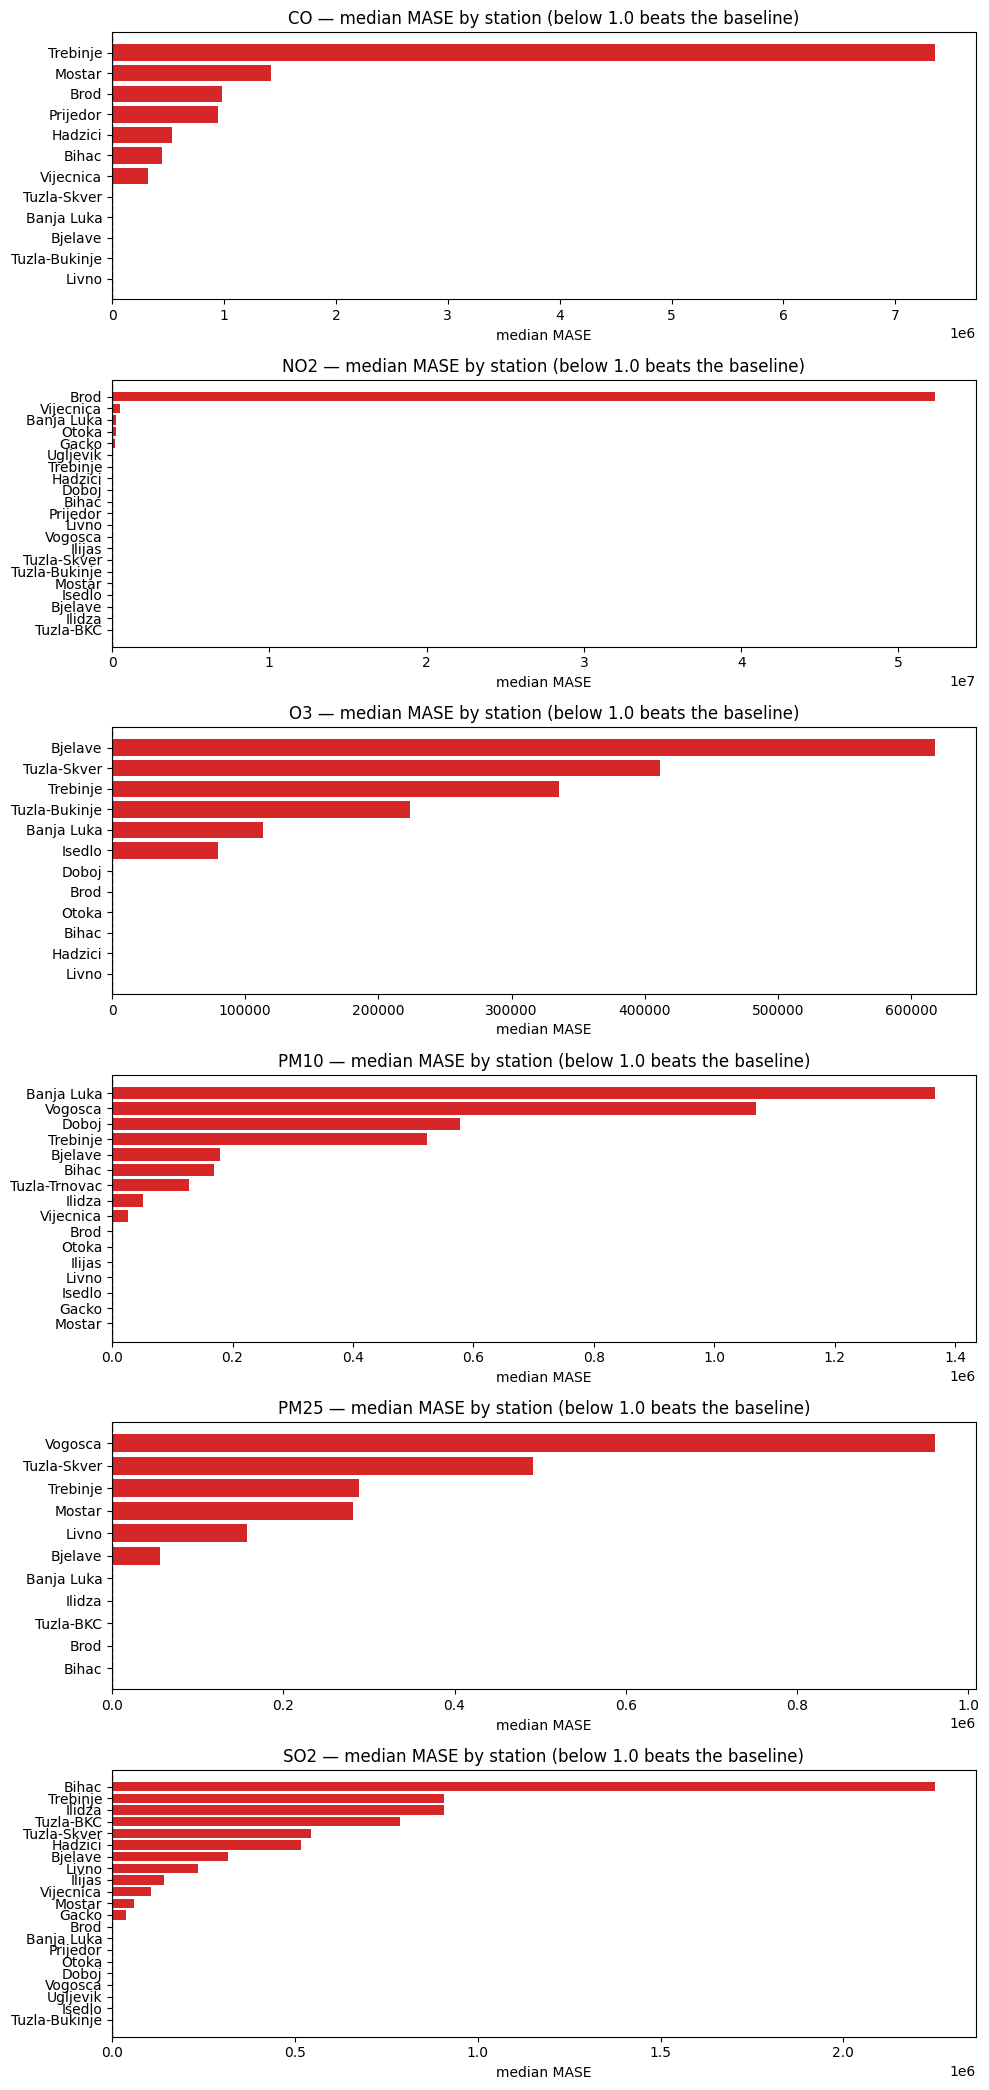

saved xlstm_mase_by_station.png


NameError: name 'final_summary' is not defined

In [3]:
result, per_pol, model = run_global()
plot_results(out_csv="xlstm_global_results.csv")
final_summary(out_csv="xlstm_global_results.csv")

In [6]:
def final_summary(out_csv="xlstm_results.csv"):
    full = pd.read_csv(out_csv)

    print(f"{len(full):,} total windows across "
          f"{full.groupby(['station', 'pollutant']).ngroups} station-pollutant series\n")

    per_pol = full.groupby("pollutant")[["mae", "rmse", "mase"]].mean()
    per_pol["median_mase"] = full.groupby("pollutant").mase.median()
    print("MASE BY POLLUTANT (mean + median — median is the trustworthy one)\n")
    print(per_pol.round(3).to_string())

    print(f"\n\nHEADLINE — mean over all windows: "
          f"MAE {full.mae.mean():.3f}  RMSE {full.rmse.mean():.3f}  MASE {full.mase.mean():.3f}")
    print(f"HEADLINE — median MASE over all windows: {full.mase.median():.3f}")

    base_path = os.path.join(SHARED_DIR, "baseline_windows.csv")
    if os.path.exists(base_path):
        base = pd.read_csv(base_path, parse_dates=["origin"])
        full2 = full.copy()
        if "origin" in full2.columns:
            full2["origin"] = pd.to_datetime(full2.origin)
        key = ["station", "pollutant", "origin"]
        base = base.merge(full2[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")

        cols = list(base.columns.intersection(full2.columns))
        if "model" not in cols:
            cols.append("model")
        allm = pd.concat([base, full2.assign(model="xlstm")[cols]], ignore_index=True)

        print("\n\nMASE BY POLLUTANT vs BASELINES (identical windows)\n")
        pivot = allm.pivot_table(index="pollutant", columns="model", values="mase")
        print(pivot.round(3).to_string())
    else:
        print(f"\n(no {base_path} found — skipping baseline merge; "
              "per-pollutant numbers above are still valid on their own)")

    return per_pol


final_summary(out_csv="xlstm_global_results.csv")

30,553 total windows across 93 station-pollutant series

MASE BY POLLUTANT (mean + median — median is the trustworthy one)

                   mae         rmse         mase  median_mase
pollutant                                                    
co           66370.094    81374.759  1294493.105   159179.312
no2        1267708.320  1557781.922  2194193.993        3.778
o3         2657807.473  3278101.272   173236.832        3.715
pm10       5097984.393  6519753.826   362046.355    30860.708
pm25       1569076.733  1915893.177   202898.776     2661.845
so2        2281676.568  2805760.642   410279.512    63858.704


HEADLINE — mean over all windows: MAE 2171171.428  RMSE 2709819.649  MASE 878837.184
HEADLINE — median MASE over all windows: 18874.971


MASE BY POLLUTANT vs BASELINES (identical windows)

model      persistence_last  persistence_t24  ratio_pm25        xlstm
pollutant                                                            
co                    1.394            1.053    

,mae,rmse,mase,median_mase
pollutant,,,,
co,6.637009e+04,8.137476e+04,1.294493e+06,159179.311832
no2,1.267708e+06,1.557782e+06,2.194194e+06,3.777534
o3,2.657807e+06,3.278101e+06,1.732368e+05,3.714708
pm10,5.097984e+06,6.519754e+06,3.620464e+05,30860.707859
pm25,1.569077e+06,1.915893e+06,2.028988e+05,2661.844906
so2,2.281677e+06,2.805761e+06,4.102795e+05,63858.703644


In [8]:
"""
By-pollutant xLSTM — one shared model PER POLLUTANT (so 6 models total:
co, no2, o3, pm10, pm25, so2), each trained across all stations that have
that pollutant. Middle ground between run_all() (95 separate models) and
run_global() (1 model for everything, which diverged — likely from mixing
chemically different pollutants with very different dynamics into one
shared embedding space).

Paste after xlstm_fast.py AND xlstm_global.py in the same notebook (reuses
DEVICE, bs, SHARED_DIR, CLEAN_CSV, build_train_origins, build_tensor_windows,
masked_l1_loss, GlobalXLSTMForecaster — all already defined there).

Usage:
    result, per_pol = run_by_pollutant()                  # all 6 pollutants
    result, per_pol = run_by_pollutant(limit=2)            # 2 at a time, resumable
    plot_results(out_csv="xlstm_by_pollutant_results.csv")
    final_summary(out_csv="xlstm_by_pollutant_results.csv")
"""

import os
import time
import torch
import numpy as np
import pandas as pd


def build_pollutant_dataset(pollutant, lookback=168, horizon=24, device=None):
    """Same idea as build_all_pairs_dataset, but filtered to one pollutant
    — the pool is every station that pollutant is 'ok' for, not every
    station-pollutant pair in the dataset."""
    device = device or DEVICE
    groups = bs.load_groups(SHARED_DIR)
    split = bs.load_split(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)

    stations = groups["by_pollutant"][pollutant]["ok"]
    print(f"[{pollutant}] building combined dataset for {len(stations)} stations...")

    all_X, all_Y, all_M, all_pair_idx = [], [], [], []
    meta = []

    for pair_id, station in enumerate(stations):
        s = panel[(station, pollutant)]
        train_start = pd.Timestamp(split["train"]["start"])
        train_end = pd.Timestamp(split["train"]["end"])
        train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
        mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

        train_origins = build_train_origins(panel, split, station, pollutant, horizon)
        if not train_origins:
            print(f"  skipping {station}-{pollutant}: 0 eligible train origins")
            continue

        X, Y, M = build_tensor_windows(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
        all_X.append(X)
        all_Y.append(Y)
        all_M.append(M)
        all_pair_idx.append(torch.full((len(train_origins),), pair_id, dtype=torch.long))

        val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)].origin.tolist()
        if val_origins:
            Xv, Yv, Mv = build_tensor_windows(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
        else:
            Xv, Yv, Mv = (torch.empty(0, lookback, 2), torch.empty(0, horizon), torch.empty(0, horizon))

        meta.append({"pair_id": pair_id, "station": station, "pollutant": pollutant,
                     "mu": mu, "sigma": sigma, "val_X": Xv, "val_Y": Yv, "val_M": Mv,
                     "val_origins": val_origins})

    if not all_X:
        return None, None, None, None, [], panel

    Xall = torch.cat(all_X).to(device)
    Yall = torch.cat(all_Y).to(device)
    Mall = torch.cat(all_M).to(device)
    pair_idx_all = torch.cat(all_pair_idx).to(device)
    print(f"[{pollutant}] combined pool: {Xall.shape[0]:,} windows across {len(meta)} stations")
    return Xall, Yall, Mall, pair_idx_all, meta, panel


def train_one_pollutant(pollutant, lookback=168, horizon=24, hidden_size=64, embed_dim=8,
                         epochs=15, batch_size=512, lr=5e-4, device=None,
                         patience=3, min_delta=1e-4):
    """Same training loop as train_global, but scoped to one pollutant's
    stations — a smaller, more homogeneous shared model. lr defaults lower
    (5e-4 vs 1e-3) since the fully-global run showed instability; if a
    pollutant's printed loss is still climbing rather than dropping, lower
    it further (1e-4) for that call."""
    device = device or DEVICE
    use_amp = device.type == "cuda"

    Xall, Yall, Mall, pair_idx_all, meta, panel = build_pollutant_dataset(pollutant, lookback, horizon, device)
    if Xall is None:
        print(f"[{pollutant}] no eligible stations — skipping")
        return None, meta, panel

    model = GlobalXLSTMForecaster(num_pairs=len(meta), embed_dim=embed_dim,
                                   hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    n = Xall.shape[0]
    best_loss, bad_epochs = float("inf"), 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        total_loss, total_n = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x, y, mask, pidx = Xall[idx], Yall[idx], Mall[idx], pair_idx_all[idx]

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                pred = model(x, pidx)
                loss = masked_l1_loss(pred, y, mask)

            if not torch.isfinite(loss):
                print(f"[{pollutant}] epoch {epoch+1}: loss went non-finite — stopping this "
                      f"pollutant early. Retry with a lower lr (e.g. lr=1e-4).")
                return model, meta, panel

            scaler.scale(loss).backward()
            if use_amp:
                scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)

        epoch_loss = total_loss / max(total_n, 1)
        print(f"[{pollutant}] epoch {epoch + 1}: train MAE (normalized)={epoch_loss:.4f}")

        if epoch_loss < best_loss - min_delta:
            best_loss, bad_epochs = epoch_loss, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{pollutant}] early stop at epoch {epoch + 1}")
                break

    return model, meta, panel


def evaluate_pollutant(model, meta, panel, horizon, pollutant, device=None):
    device = device or DEVICE
    model.eval()
    rows = []

    for m in meta:
        station, mu, sigma = m["station"], m["mu"], m["sigma"]
        Xv, val_origins, pair_id = m["val_X"], m["val_origins"], m["pair_id"]
        if len(val_origins) == 0:
            continue

        Xv = Xv.to(device)
        pidx = torch.full((Xv.shape[0],), pair_id, dtype=torch.long, device=device)
        with torch.no_grad():
            pred_norm = model(Xv, pidx).cpu().numpy()
        preds = pred_norm * sigma + mu

        for i, origin in enumerate(val_origins):
            y, mask = bs.target(panel, station, pollutant, origin, horizon)
            ctx = bs.context(panel, station, pollutant, origin, 512)
            scale = bs.mase_scale(ctx)
            rows.append({"model": "xlstm_by_pollutant", "station": station, "pollutant": pollutant,
                        "origin": origin, **bs.score(preds[i], y, mask, scale)})

    return pd.DataFrame(rows)


def run_by_pollutant(lookback=168, horizon=24, hidden_size=64, embed_dim=8,
                      epochs=15, batch_size=512, lr=5e-4, device=None,
                      out_csv="xlstm_by_pollutant_results.csv", limit=None):
    """Resumable, same philosophy as run_all(): skips pollutants already
    fully written to out_csv, appends incrementally, stop/resume any time.
    Only 6 possible units of work instead of 95, so `limit` rarely matters,
    but it's there in case one pollutant's stations make for a slow batch."""
    device = device or DEVICE

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(prev.pollutant.unique())
        print(f"{len(done)} pollutants already in {out_csv}, skipping those")

    remaining = [p for p in bs.POLLUTANTS if p not in done]
    print(f"{len(bs.POLLUTANTS)} total pollutants, {len(remaining)} remaining: {remaining}")

    batch = remaining[:limit] if limit else remaining

    for pollutant in batch:
        t0 = time.time()
        try:
            model, meta, panel = train_one_pollutant(
                pollutant, lookback=lookback, horizon=horizon, hidden_size=hidden_size,
                embed_dim=embed_dim, epochs=epochs, batch_size=batch_size, lr=lr, device=device)
            if model is None:
                continue
            result = evaluate_pollutant(model, meta, panel, horizon, pollutant, device=device)
            if len(result) == 0:
                continue
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)
        except Exception as e:
            print(f"SKIPPED {pollutant}: {e}")
        print(f"[{pollutant}] wall time: {time.time() - t0:.1f}s\n")

    full = pd.read_csv(out_csv) if os.path.exists(out_csv) else pd.DataFrame()
    if len(full):
        per_pol = bs.aggregate(full.to_dict("records"))
        print("\nFULL SUMMARY SO FAR — by-pollutant xLSTM, per pollutant, native units:\n")
        print(per_pol)
    else:
        per_pol = None
    return full, per_pol

6 total pollutants, 6 remaining: ['pm10', 'pm25', 'so2', 'no2', 'o3', 'co']


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[pm10] building combined dataset for 16 stations...
[pm10] combined pool: 12,995 windows across 16 stations


/tmp/ipykernel_1352/3913715060.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


[pm10] epoch 1: loss went non-finite — stopping this pollutant early. Retry with a lower lr (e.g. lr=1e-4).
[pm10] wall time: 10.8s



...

[o3] epoch 1: loss went non-finite — stopping this pollutant early. Retry with a lower lr (e.g. lr=1e-4).
[o3] wall time: 10.0s



/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[co] building combined dataset for 13 stations...
[co] combined pool: 10,180 windows across 13 stations


/tmp/ipykernel_1352/3913715060.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


[co] epoch 1: loss went non-finite — stopping this pollutant early. Retry with a lower lr (e.g. lr=1e-4).
[co] wall time: 9.9s


FULL SUMMARY SO FAR — by-pollutant xLSTM, per pollutant, native units:

                                       mae          rmse          mase
model              pollutant                                          
xlstm_by_pollutant co         9.855806e+04  1.213895e+05  1.804333e+06
                   no2        1.340982e+06  1.645429e+06  2.539605e+05
                   o3         6.843260e+06  8.329701e+06  6.646826e+05
                   pm10       2.047028e+06  2.525363e+06  1.686845e+05
                   pm25       1.420063e+06  1.724393e+06  1.987611e+05
                   so2        1.726335e+06  2.124023e+06  4.876348e+05


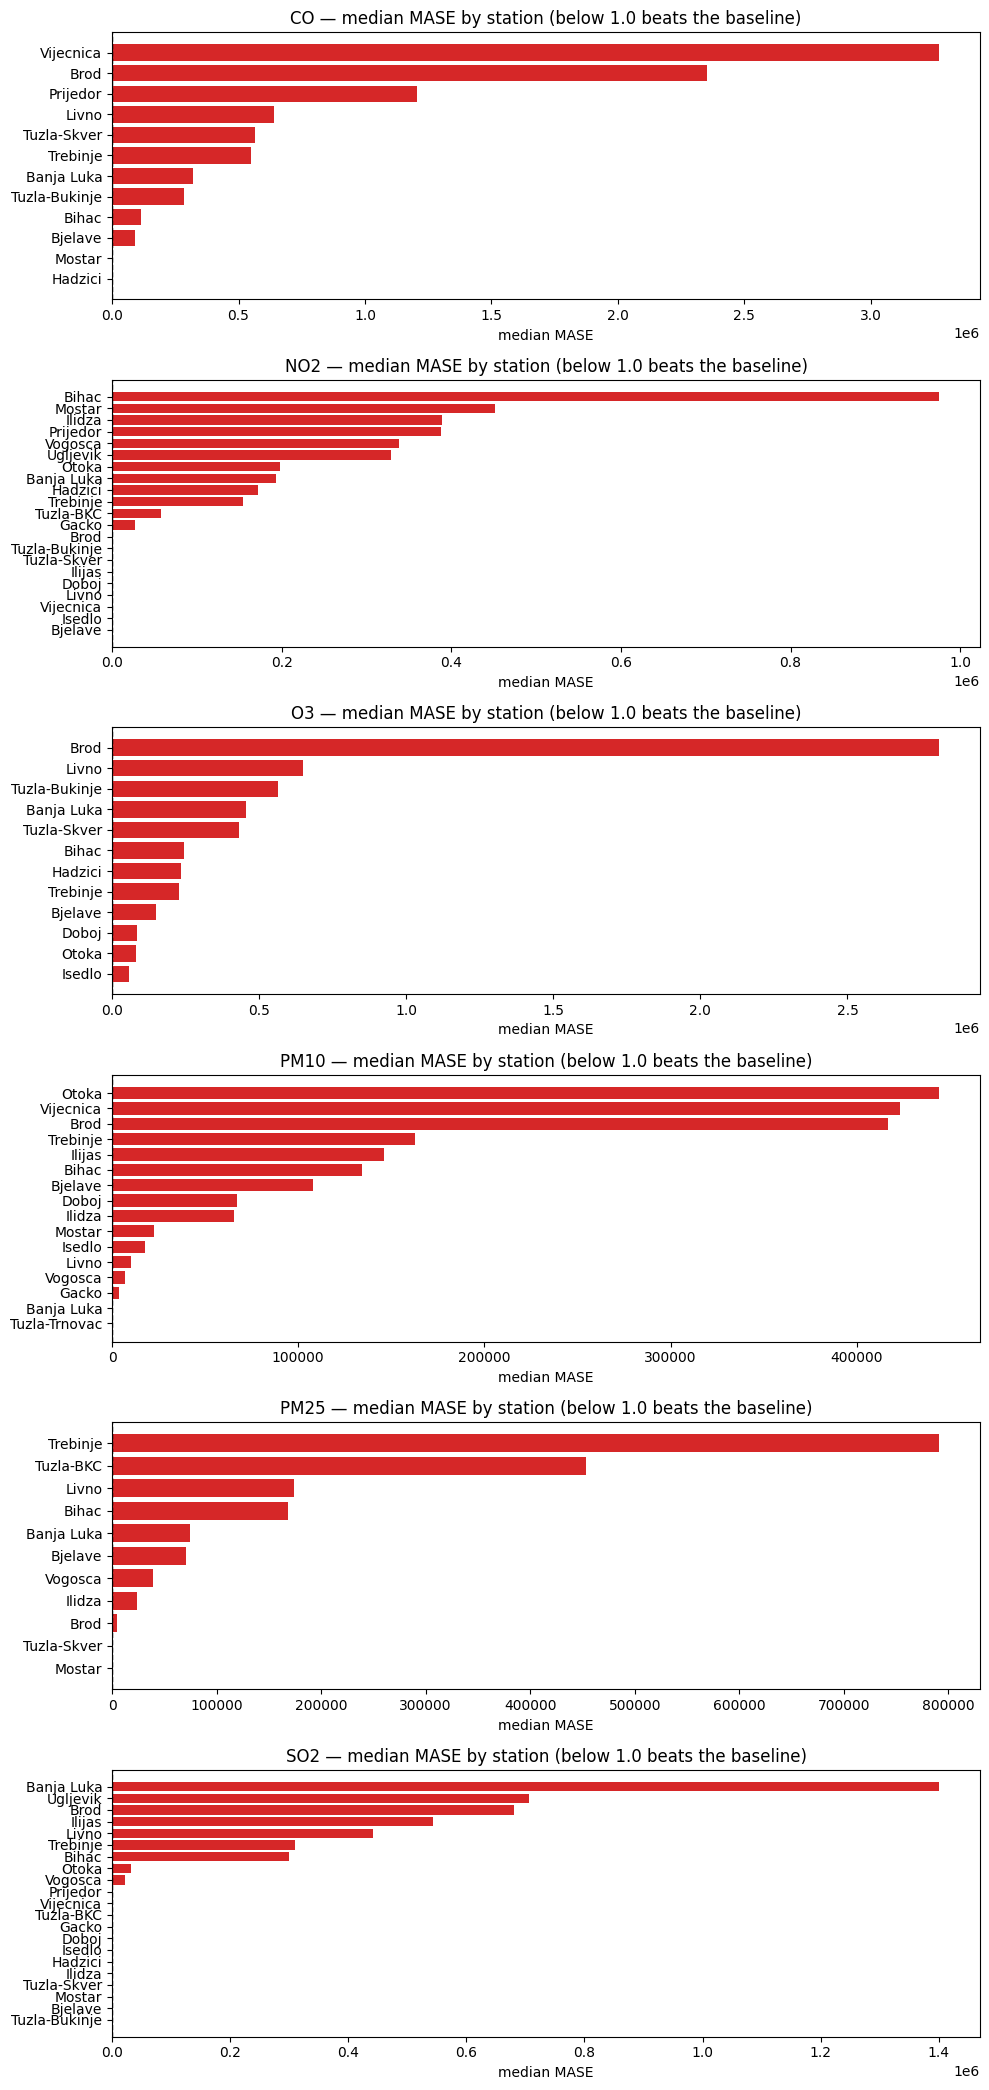

saved xlstm_mase_by_station.png
30,553 total windows across 93 station-pollutant series

MASE BY POLLUTANT (mean + median — median is the trustworthy one)

                   mae         rmse         mase  median_mase
pollutant                                                    
co           98558.063   121389.525  1804333.170   297249.180
no2        1340982.215  1645429.133   253960.477    57087.064
o3         6843260.190  8329700.635   664682.568   288201.560
pm10       2047027.544  2525363.278   168684.487    64040.111
pm25       1420062.507  1724393.461   198761.119    51763.713
so2        1726334.611  2124023.176   487634.815    12940.494


HEADLINE — mean over all windows: MAE 2093920.057  RMSE 2562139.576  MASE 548418.493
HEADLINE — median MASE over all windows: 101630.042


MASE BY POLLUTANT vs BASELINES (identical windows)

model      persistence_last  persistence_t24  ratio_pm25        xlstm
pollutant                                                            
co             

,mae,rmse,mase,median_mase
pollutant,,,,
co,9.855806e+04,1.213895e+05,1.804333e+06,297249.180449
no2,1.340982e+06,1.645429e+06,2.539605e+05,57087.064142
o3,6.843260e+06,8.329701e+06,6.646826e+05,288201.560068
pm10,2.047028e+06,2.525363e+06,1.686845e+05,64040.110707
pm25,1.420063e+06,1.724393e+06,1.987611e+05,51763.712923
so2,1.726335e+06,2.124023e+06,4.876348e+05,12940.493867


In [9]:
result, per_pol = run_by_pollutant()
plot_results(out_csv="xlstm_by_pollutant_results.csv")
final_summary(out_csv="xlstm_by_pollutant_results.csv")